# Лабораторная работа №4
## Линейные модели, SVM и деревья решений


### Описание задания
1. Выбрать датасет для задачи классификации или регрессии.
2. При необходимости обработать пропуски и категориальные признаки.
3. Разделить выборку на обучающую и тестовую (`train_test_split`).
4. Обучить модели: линейную, SVM, дерево решений.
5. Оценить качество по двум метрикам и сравнить результаты.
6. Построить график важности признаков в дереве решений.
7. Визуализировать дерево решений или вывести правила в текстовом виде.

In [18]:
# 1. Импорт библиотек и настройка окружения

from pathlib import Path

import io

import json



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



from sklearn.datasets import load_wine

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline



from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text



from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report



pd.set_option("display.max_columns", 120)

pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42



project_dir = Path.cwd()

artifacts_dir = project_dir / "artifacts" / "lab4"

artifacts_dir.mkdir(parents=True, exist_ok=True)



print("Рабочая директория:", project_dir)

print("Папка для артефактов:", artifacts_dir)

Рабочая директория: d:\6 сем\тмо\lab3
Папка для артефактов: d:\6 сем\тмо\lab3\artifacts\lab4


In [19]:
# 2. Загрузка датасета

def load_dataset():

    data = load_wine(as_frame=True)

    df_local = data.frame.copy()

    df_local = df_local.rename(columns={"target": "label"})

    return df_local, "classification", "sklearn Wine"





df, task_type, dataset_name = load_dataset()



print("Выбранный датасет:", dataset_name)

print("Тип задачи:", task_type)

print("Размерность:", df.shape)

print("Целевая переменная:", "label")

Выбранный датасет: sklearn Wine
Тип задачи: classification
Размерность: (178, 14)
Целевая переменная: label


### Пояснение к датасету

Используется датасет **Wine** из `sklearn`.



- Объект: образец вина.

- Признаки: физико-химические характеристики.

- Целевая переменная `label`: класс вина (0/1/2).



Задача: **многоклассовая классификация**.

In [20]:
# 3. Первичный анализ и подготовка данных
print("Первые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())

missing = df.isna().sum().sort_values(ascending=False)
print("Топ-10 признаков по числу пропусков:")
display(missing.head(10).to_frame("missing_count"))

print("Распределение целевой переменной:")
display(df["label"].value_counts(dropna=False).to_frame("count"))

TARGET_COL = "label"
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}")

Первые 5 строк:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

,missing_count
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


Распределение целевой переменной:


,count
label,
1,71
0,59
2,48


Числовых признаков: 13
Категориальных признаков: 0


In [21]:
# 4. Разделение выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Доли классов в train:")
print(y_train.value_counts(normalize=True).sort_index())
print("Доли классов в test:")
print(y_test.value_counts(normalize=True).sort_index())

Размер X_train: (142, 13)
Размер X_test: (36, 13)
Доли классов в train:
label
0    0.330986
1    0.401408
2    0.267606
Name: proportion, dtype: float64
Доли классов в test:
label
0    0.333333
1    0.388889
2    0.277778
Name: proportion, dtype: float64


In [22]:
# 5. Обучение моделей и оценка качества

def evaluate_classifier(model, X_tr, y_tr, X_te, y_te, model_name="model"):

    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)

    is_binary = y_te.nunique() == 2



    if is_binary:

        f1 = f1_score(y_te, preds, average="binary", zero_division=0)

    else:

        f1 = f1_score(y_te, preds, average="macro", zero_division=0)



    metrics = {

        "model": model_name,

        "accuracy": accuracy_score(y_te, preds),

        "f1": f1,

    }



    if hasattr(model, "predict_proba"):

        proba = model.predict_proba(X_te)

        if is_binary:

            metrics["roc_auc"] = roc_auc_score(y_te, proba[:, 1])

        else:

            metrics["roc_auc"] = roc_auc_score(y_te, proba, multi_class="ovr", average="macro")

    else:

        metrics["roc_auc"] = np.nan



    return metrics, preds



models = {

    "LogisticRegression": Pipeline(steps=[

        ("preprocessor", preprocessor),

        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),

    ]),

    "SVM (RBF)": Pipeline(steps=[

        ("preprocessor", preprocessor),

        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)),

    ]),

    "DecisionTree": Pipeline(steps=[

        ("preprocessor", preprocessor),

        ("model", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),

    ]),

}



metrics_rows = []

predictions = {}



for name, model in models.items():

    m, p = evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name=name)

    metrics_rows.append(m)

    predictions[name] = p



metrics_table = pd.DataFrame(metrics_rows).sort_values(by=["f1", "accuracy"], ascending=False)



print("Сравнение моделей на тестовой выборке:")

display(metrics_table)



for name in ["LogisticRegression", "SVM (RBF)", "DecisionTree"]:

    print(f"\nClassification report: {name}")

    print(classification_report(y_test, predictions[name], zero_division=0))

Сравнение моделей на тестовой выборке:


,model,accuracy,f1,roc_auc
0,LogisticRegression,0.972222,0.970962,1.000000
1,SVM (RBF),0.972222,0.970962,1.000000
2,DecisionTree,0.944444,0.945741,0.954293



Classification report: LogisticRegression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


Classification report: SVM (RBF)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


Classification report: DecisionTree
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1   

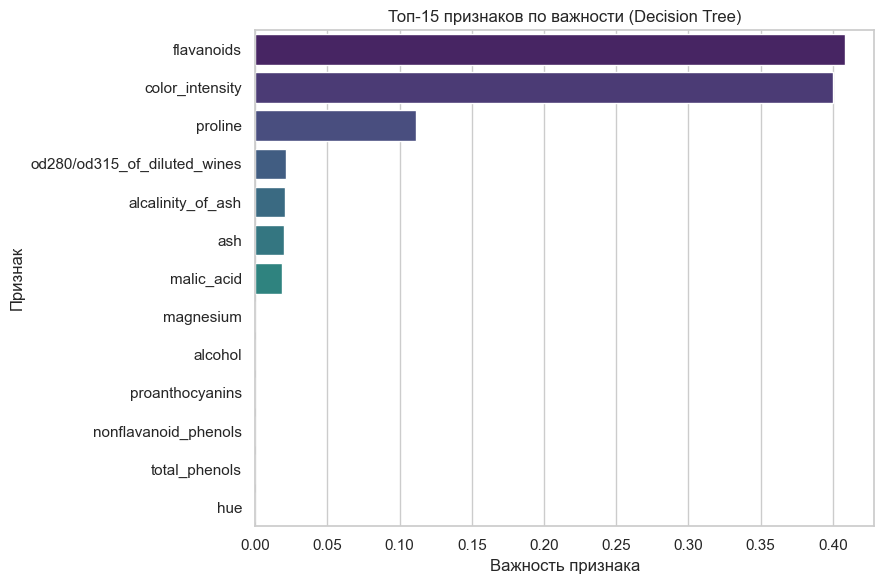

,feature,importance
6,flavanoids,0.408073
9,color_intensity,0.400189
12,proline,0.110985
11,od280/od315_of_diluted_wines,0.020986
3,alcalinity_of_ash,0.020865
2,ash,0.020163
1,malic_acid,0.018738
4,magnesium,0.000000
0,alcohol,0.000000
8,proanthocyanins,0.000000


In [23]:
# 6. Важность признаков для дерева решений

tree_pipeline = models["DecisionTree"]

tree_model = tree_pipeline.named_steps["model"]

tree_preprocessor = tree_pipeline.named_steps["preprocessor"]

feature_names = tree_preprocessor.get_feature_names_out()

feature_names = [name.split("__", 1)[-1] for name in feature_names]



importance_df = pd.DataFrame({

    "feature": feature_names,

    "importance": tree_model.feature_importances_,

}).sort_values("importance", ascending=False)



top_n = 15

top_importance = importance_df.head(top_n).copy()



plt.figure(figsize=(9, 6))

sns.barplot(

    data=top_importance,

    x="importance",

    y="feature",

    hue="feature",

    palette="viridis",

    dodge=False,

    legend=False,

)

plt.title("Топ-15 признаков по важности (Decision Tree)")

plt.xlabel("Важность признака")

plt.ylabel("Признак")

plt.tight_layout()

plt.savefig(artifacts_dir / "feature_importance_tree.png", dpi=150)

plt.show()



display(top_importance)

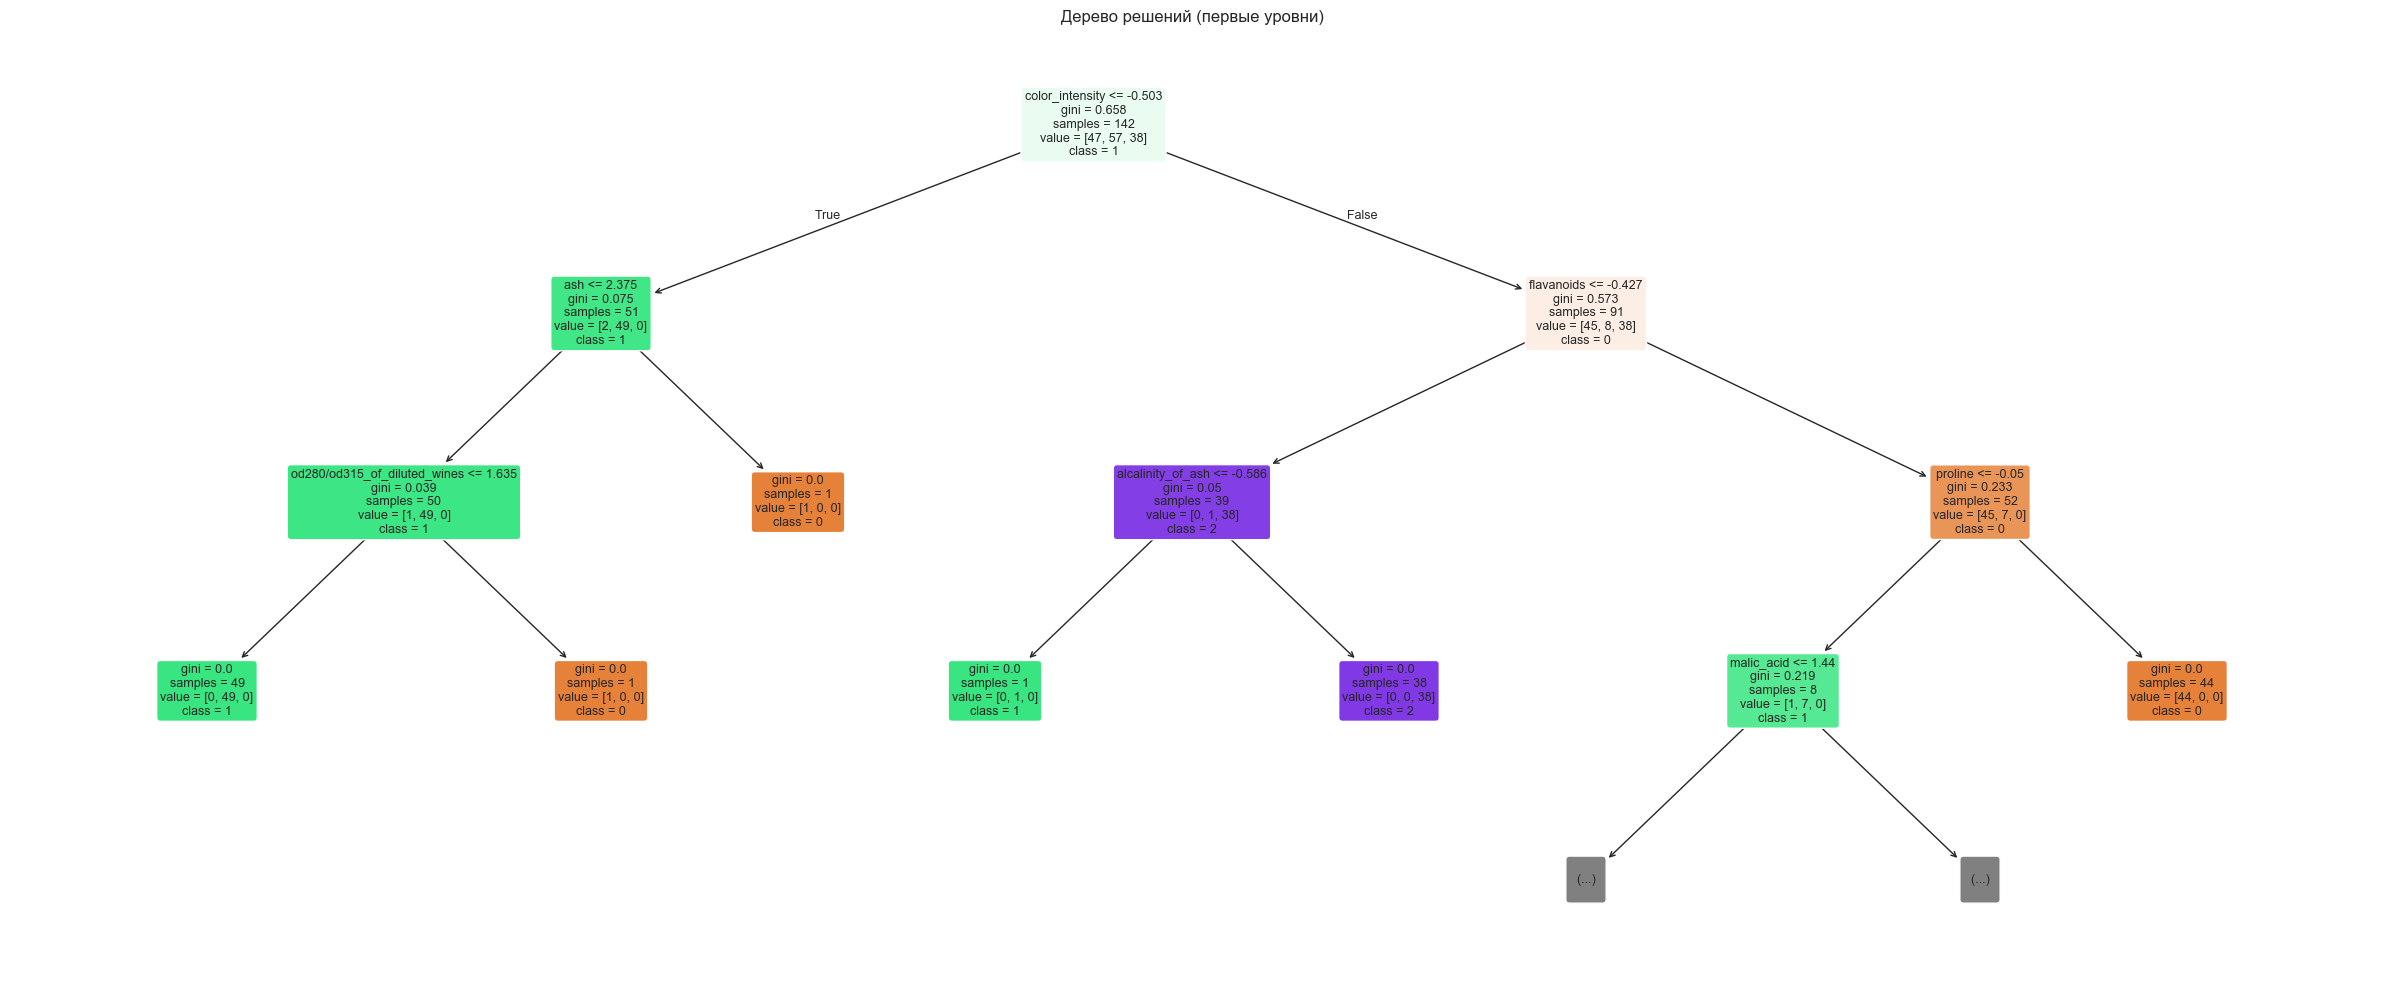

Текстовые правила дерева (до глубины 4):
|--- color_intensity <= -0.50
|   |--- ash <= 2.37
|   |   |--- od280/od315_of_diluted_wines <= 1.64
|   |   |   |--- class: 1
|   |   |--- od280/od315_of_diluted_wines >  1.64
|   |   |   |--- class: 0
|   |--- ash >  2.37
|   |   |--- class: 0
|--- color_intensity >  -0.50
|   |--- flavanoids <= -0.43
|   |   |--- alcalinity_of_ash <= -0.59
|   |   |   |--- class: 1
|   |   |--- alcalinity_of_ash >  -0.59
|   |   |   |--- class: 2
|   |--- flavanoids >  -0.43
|   |   |--- proline <= -0.05
|   |   |   |--- malic_acid <= 1.44
|   |   |   |   |--- class: 1
|   |   |   |--- malic_acid >  1.44
|   |   |   |   |--- class: 0
|   |   |--- proline >  -0.05
|   |   |   |--- class: 0



In [24]:
# 7. Визуализация дерева и текстовые правила

class_names = [str(cls) for cls in tree_model.classes_]



plt.figure(figsize=(24, 10))

plot_tree(

    tree_model,

    feature_names=feature_names,

    class_names=class_names,

    filled=True,

    rounded=True,

    max_depth=3,

    fontsize=9,

)

plt.title("Дерево решений (первые уровни)")

plt.tight_layout()

plt.savefig(artifacts_dir / "decision_tree_plot.png", dpi=150)

plt.show()



rules = export_text(tree_model, feature_names=feature_names, max_depth=4)

print("Текстовые правила дерева (до глубины 4):")

print(rules)

In [25]:
# 8. Сохранение артефактов
metrics_table.to_csv(artifacts_dir / "models_metrics_comparison.csv", index=False)
importance_df.to_csv(artifacts_dir / "decision_tree_feature_importance.csv", index=False)

best_model_row = metrics_table.iloc[0].to_dict()
payload = {
    "dataset": dataset_name,
    "task_type": task_type,
    "random_state": RANDOM_STATE,
    "best_model_on_test": best_model_row,
    "models_test_metrics": metrics_table.to_dict(orient="records"),
}

with open(artifacts_dir / "summary.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

print("Артефакты сохранены в:", artifacts_dir)
for item in sorted(artifacts_dir.glob("*")):
    print(" -", item.name)

Артефакты сохранены в: d:\6 сем\тмо\lab3\artifacts\lab4
 - decision_tree_feature_importance.csv
 - decision_tree_plot.png
 - feature_importance_tree.png
 - models_metrics_comparison.csv
 - summary.json


## Выводы
1. Были обучены три модели: логистическая регрессия, SVM и дерево решений.
2. Качество оценено метриками `accuracy` и `f1` (дополнительно `roc_auc`).
3. Проведено сравнение моделей на тестовой выборке.
4. Построен график важности признаков дерева решений.
5. Выполнена визуализация дерева и выведены текстовые правила.

Таким образом, цель лабораторной работы достигнута: изучены и сравнены линейная модель, SVM и дерево решений на задаче классификации.